## Simulation of Hofsadter Butterfly

In [1]:
import numpy as np
from math import comb
from tabulate import tabulate
import matplotlib.pyplot as plt
from itertools import combinations
import scipy.linalg as la
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors 
import math
from sympy import *
from fractions import Fraction 
from matplotlib import cm
from matplotlib.colors import Normalize

### parameters of the simulation

In [2]:

L_x=3
L_y=3
PBC_x=True
PBC_y=True
T_x=1
T_y=1
p=1
q=3
N=1 #number of particles


### State from labels, double and single index dictionary

In [3]:
def get_single_index_from_double(n,m, L_x, L_y): #n is column, m is row
    if n >= L_x or m >= L_y:
        raise ValueError("n and m must be within the bounds of the lattice size.")
    index=m*L_x+n
    return index

def get_double_index_from_single(index, L_x, L_y):
    n=index % L_x
    m=index//L_x 
    return n,m

### Get state from labels and viceversa

In [4]:
def get_state_from_label(state_number, L_x, L_y):
    state=np.zeros(L_y*L_x, dtype=bool)
    for i in range((L_x*L_y-1), -1, -1):
        if state_number >= (2**i):
            state[i] = True
            state_number=state_number - (2**i)
    return state


def get_label_from_state(state, L_x, L_y):
    state_number=0
    for i in range(L_x*L_y-1, -1, -1):
        if state[i]:
            state_number += 2**i
    return state_number

def get_double_index_state_from_label(state_number, L_x, L_y):
    state=get_state_from_label(state_number, L_x=L_x, L_y=L_y)
    double_index_state=np.zeros((L_x,L_y), dtype=bool)
    for i in range(L_x):
        for j in range(L_y):
            double_index_state[i,j]=state[get_single_index_from_double(i,j, L_x=L_x, L_y=L_y)]
    return double_index_state

def get_number_of_states_per_fixed_number(N, L_x, L_y):
    fixed_size=comb(L_x*L_y , N)
    return fixed_size

def get_state_list(N, L_x, L_y):
    """
    Directly generates a list of boolean NumPy arrays for all states.

    Warning: This will be very slow and memory-intensive for large systems.
    """
    total_sites = L_x * L_y
    
    # Check if the problem is too large to handle
    num_states = comb(total_sites, N)
    # Estimate memory usage: num_states * num_sites_per_state * 1 byte/bool
    mem_estimate_gb = (num_states * total_sites) / (1024**3)
    if mem_estimate_gb > 1:
        print(f"Warning: This operation will create a list of {num_states:,} arrays "
              f"and may consume over {mem_estimate_gb:.2f} GB of RAM.")

    state_list = []
    for occupied_indices in combinations(range(total_sites), N):
        # 1. Create a 1D array of False values
        state = np.full(total_sites, False, dtype=bool)
        
        # 2. Use the indices to set occupied sites to True (advanced indexing)
        state[list(occupied_indices)] = True
        
        # 3. Reshape to 2D and append to the list
        state_list.append(state)
        
    return state_list

### Functions to calcualte topology

##### Via Bott Method

In [5]:
def get_occupied_vectors( num_occupied_states, eigenvectors):
    occupied_vectors=[]
    # eigenvalues, eigenvectors=np.linalg.eigh(get_hamiltonian_for_fixed_number_of_electrons(N, PBC, T_y, T_x, p, q))
    occupied_vectors= eigenvectors[:, :(num_occupied_states)] 
    #P = occupied_vectors @ occupied_vectors.T.conj()
    # print(f"Occupied vectors shape: {occupied_vectors.shape}")
    # print(eigenvectors)
    return occupied_vectors

def get_U_V_matrices(N=N,L_x=L_x, L_y=L_y):
    fixed_number=get_number_of_states_per_fixed_number(N=N, L_x=L_x, L_y=L_y)
    u_1p = [complex(m, 0) for m in range(L_x) for n in range(L_y)]
    v_1p = [complex(n, 0) for m in range(L_x) for n in range(L_y)]
    N_particle_basis = list(combinations(range(L_x*L_y), N))                      ###DA IMPLEMENTARE SOPRA FORSE
    U_1 = np.array([sum(u_1p[p] for p in state) for state in N_particle_basis])
    V_1=  np.array([sum(v_1p[p] for p in state) for state in N_particle_basis])
    U = np.diag(np.exp(1j * 2 * np.pi * U_1 / L_x))
    V = np.diag(np.exp(1j * 2 * np.pi * V_1 / L_y))
    return U, V

def get_chern_number(num_occupied_states,eigenvectors, N=N, L_x=L_x, L_y=L_y):
    U_tilde, V_tilde = get_U_V_matrices(N=N, L_x=L_x, L_y=L_y)
    occupied_vectors = get_occupied_vectors( num_occupied_states, eigenvectors)
    U_proj = occupied_vectors.T.conj() @ U_tilde @ occupied_vectors
    V_proj = occupied_vectors.T.conj() @ V_tilde @ occupied_vectors
    Bott_matrix = V_proj @ U_proj @ V_proj.T.conj() @ U_proj.T.conj()
    eigvals = la.eigvals(Bott_matrix)
    chern_number = np.sum(np.angle(eigvals)) / (2 * np.pi)

    return chern_number


def analyze_topology_at_flux(eigenvalues, eigenvectors,q, N, L_x, L_y, print_chern=False):
    """
    Analyzes a single Hamiltonian to find its stable Chern invariants
    by identifying the q-1 largest energy gaps.
    """ 
    #THIS FUNCTION IS CONCEPTUALLY CORRECT ONLY WHEN p/q IS A REDUCED FRACTION WITH BOT p and q PRIMES. Only in this case we know there are q-1 gaps and q bands.
    
    # --- This section is now updated with your improved logic ---
    if q > 1:
        gaps = np.diff(eigenvalues)
        # Find the indices of the q-1 largest gaps in the spectrum
        major_gap_indices = np.argsort(gaps)[-(q-1):]
    else:
        # If q=1, there is only one band and no gaps.
        major_gap_indices = np.array([], dtype=int)

    # Calculate Chern number ONLY at these major gaps
    chern_at_gaps = {}
    for k_gap in major_gap_indices:
        num_occupied = k_gap + 1
        chern_num = get_chern_number(num_occupied_states=num_occupied, eigenvectors=eigenvectors, N=N, L_x=L_x, L_y=L_y)
        print(f"Chern number at gap {k_gap}: {chern_num}")
        chern_at_gaps[num_occupied] = chern_num#round(chern_num)
        
    num_eigenvalues = len(eigenvalues)
    chern_assignments = np.zeros(num_eigenvalues, dtype=float)
    
    current_chern = 0
    sorted_gap_keys = sorted(chern_at_gaps.keys()) #get umber of occupied states at each band
    
    start_index = 0
    for num_occupied in sorted_gap_keys:
        # Assign the current Chern number to the states in the band
        chern_assignments[start_index:num_occupied] = current_chern
        # Update the Chern number for the next band
        current_chern = chern_at_gaps[num_occupied]
        start_index = num_occupied
        
    # Assign the final Chern number to the last band
    chern_assignments[start_index:] = current_chern
            
    return chern_assignments


##### Via Chern number

### Hamiltonian

#### $H=T(\sum_{<i,j>}e^{i\theta_{n,m}}c^{\dag}_{n^{\prime},m^{\prime}}c_{n,m}+h.c.)$ with $\theta_{m,n}=\frac{e}{\hbar}\int_{m,n}^{m\prime,n\prime}A\cdot dl$

#### function needed to build hamiltonian

In [6]:
def get_phases(q,p, L_x, L_y):
    if L_x%q != 0:
        raise ValueError("L_x must be divisible by q") #condition can be relaxed when not using PBC, do in the future
    else:
        phases=np.zeros(q, dtype=complex)
        for i in range(q):
            phases[i] = np.exp(-2j * p * np.pi * i / q)
    return phases  
    

def reduce_array_for_periodicity(state, shift, q, L_x, L_y): #this takes the full array value and contracts by column, shift is the step in the periodicty to account for
    reduced_state=np.zeros((L_x//q,L_y), dtype=bool)
    for i in range(L_x//q):
        for j in range(L_y):
            reduced_state[i,j]= state[i*q+shift,j]
    return reduced_state


def check_if_occupied(n,m,state): ## check if the site (n,m) is occupied
    if state[get_single_index_from_double(n,m, L_x=L_x, L_y=L_y)] == True:
        return True
    else:
        return False
    

def calculate_IPR(vector): #Inverse Participation Ratio to filter out edge states in OBC
    vector = np.abs(vector) ** 2
    ipr = np.sum(vector ** 2)
    return ipr


def find_index_of_state(state_list, target_state):
    #print(target_state)
    for temp, state in enumerate(state_list):
        if np.array_equal(state, target_state): 
            return temp
    return -1

#### Hamiltonian per fixed number of particle

In [7]:
import numpy as np

def get_hamiltonian_for_fixed_number_of_electrons(N, state_list, L_x, L_y, PBC_x, PBC_y, T_y, T_x, p, q, progress_bar=True):
    """
    Builds the Hamiltonian for a fixed number of electrons with optimized performance.
    """
    fixed_size = len(state_list)
    H = np.zeros((fixed_size, fixed_size), dtype=complex)
    phases = get_phases(q, p, L_x=L_x, L_y=L_y)

    # --- Optimization 1: Create a state-to-index mapping ---
    state_to_index = {tuple(state): i for i, state in enumerate(state_list)}

    # Pre-calculate occupied sites for each state
    occupied_sites = [np.where(state)[0] for state in state_list]

    for i, ket_state_tuple in enumerate(state_to_index.keys()):
        if progress_bar and (i + 1) % 100 == 0:  # More efficient progress update
            print(f"Processing state {i + 1}/{fixed_size}")

        ket_state = np.array(ket_state_tuple)
        
        # Iterate over occupied sites directly
        for site_index in occupied_sites[i]:
            n, m = get_double_index_from_single(site_index, L_x=L_x, L_y=L_y)

            # --- Hopping in y-direction ---
            for k in [-1, 1]:
                m_k = m + k
                if PBC_y:
                    m_k %= L_y
                
                if 0 <= m_k < L_y:
                    new_site_index = get_single_index_from_double(n, m_k, L_x=L_x, L_y=L_y)
                    if not ket_state[new_site_index]:  # Check if the new site is empty, two fermion creators are zero
                        bra_state_tuple = list(ket_state_tuple)
                        bra_state_tuple[site_index] = False
                        bra_state_tuple[new_site_index] = True
                        bra_index = state_to_index[tuple(bra_state_tuple)]
                        
                        # Apply Peierls phase for y-hopping
                        phase_factor = 1.0
                        period_index = n % q
                        if phases is not None:
                            phase_factor = phases[period_index]**k

                        H[bra_index, i] -= phase_factor * T_y

            # --- Hopping in x-direction ---
            for k in [-1, 1]:
                n_k = n + k
                if PBC_x:
                    n_k %= L_x
                
                if 0 <= n_k < L_x:
                    new_site_index = get_single_index_from_double(n_k, m, L_x=L_x, L_y=L_y)
                    if not ket_state[new_site_index]:  # Check if the new site is empty
                        bra_state_tuple = list(ket_state_tuple)
                        bra_state_tuple[site_index] = False
                        bra_state_tuple[new_site_index] = True
                        bra_index = state_to_index[tuple(bra_state_tuple)]
                        
                        H[bra_index, i] -= T_x
                        
    return H


### Get spectrum 

#### Real space

In [8]:
def get_spectrum_in_real_space(N=N, L_x=L_x, L_y=L_y, PBC_x=PBC_x, PBC_y=PBC_y, T_x=T_x, T_y=T_y, p=p, q=q, progress_bar=False):
    state_list = get_state_list(N=N, L_x=L_x, L_y=L_y)
    H = get_hamiltonian_for_fixed_number_of_electrons(N=N, state_list=state_list, L_x=L_x, L_y=L_y, PBC_x=PBC_x, PBC_y=PBC_y, T_x=T_x, T_y=T_y, p=p, q=q, progress_bar=progress_bar)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    return eigenvalues, eigenvectors

In [9]:
def get_fourier_transform_matrix(L_x, L_y):
    """
    Builds the 2D Fourier transform matrix using vectorization and the Kronecker product.
    """
    num_sites = L_x * L_y

    # 1. Build the 1D Fourier matrix for the x-dimension
    j_coords = np.arange(L_x)
    n_coords = np.arange(L_x)
    # Use broadcasting to create the exponent matrix for U_x
    k_dot_r_x = (j_coords[:, np.newaxis] * n_coords) / L_x
    U_x = (1 / np.sqrt(L_x)) * np.exp(-2j * np.pi * k_dot_r_x)

    # 2. Build the 1D Fourier matrix for the y-dimension
    l_coords = np.arange(L_y)
    m_coords = np.arange(L_y)
    # Use broadcasting to create the exponent matrix for U_y
    k_dot_r_y = (l_coords[:, np.newaxis] * m_coords) / L_y
    U_y = (1 / np.sqrt(L_y)) * np.exp(-2j * np.pi * k_dot_r_y)

    # 3. Combine them using the Kronecker product
    # The normalization factor is automatically handled: 1/sqrt(Lx) * 1/sqrt(Ly) = 1/sqrt(Lx*Ly)
    U = np.kron(U_x, U_y)
    
    return U

# def get_fourier_transform_matrix_per_block(L_x, L_y, q):  #To build the Fourier transform matrix with the block structure

#     num_sites = L_x * L_y
#     U = np.zeros((num_sites, num_sites), dtype=complex)

#     L_x_q = L_x // q  # Reduced size for the block structure
#     for i in range(q):  # Loop over the q blocks
#         for j in range(L_x_q): # kx index
#             k_x_q = 2 * np.pi * j / L_x_q
#             for l in range(L_y): # ky index
#                 k_y = 2 * np.pi * l / L_y
#                 k_index = get_single_index_from_double(i*L_x_q+j, l, L_x=L_x, L_y=L_y)
#                 for n in range(L_x_q): # real space x index
#                     for m in range(L_y): # real space y index
#                         r_index = get_single_index_from_double(q*j+i, m, L_x=L_x, L_y=L_y)
#                         U[k_index, r_index] = (np.sqrt(q) / np.sqrt(num_sites)) * np.exp(-1j * (k_x_q * n + k_y * m))
#     return U


def reorder_k_basis(H_k_full, L_x, L_y, q):
    """
    Reorders the basis of the k-space Hamiltonian to make it block-diagonal.
    
    The standard k-basis is ordered by (kx, ky). This function reorders it
    to group k-vectors that are coupled by the magnetic field, revealing
    the block-diagonal structure of q x q matrices.

    """
    Lx_q = L_x // q
    
    # Create the permutation map
    perm_map = []
    for l in range(L_y): # ky index
        for j_reduced in range(Lx_q): # reduced kx index
            for band_index in range(q): # band index
                # Original kx index j
                j = j_reduced + band_index * Lx_q
                
                original_index = get_single_index_from_double(j, l, L_x=L_x, L_y=L_y)
                perm_map.append(original_index)
    
    # Apply the permutation to rows and columns
    H_reordered = H_k_full[perm_map, :]
    H_reordered = H_reordered[:, perm_map]
    
    return H_reordered


def visualize_matrices(N, L_x, L_y, PBC_x, PBC_y, T_x, T_y, p, q):

    state_list=get_state_list(N=N, L_x=L_x, L_y=L_y)
    print("Building real-space Hamiltonian H_real...")
    H_real = get_hamiltonian_for_fixed_number_of_electrons(N=N, state_list=state_list,L_x=L_x, L_y=L_y, PBC_x=PBC_x, PBC_y=PBC_y, T_x=T_x, T_y=T_y, p=p, q=q , progress_bar=True)

    print("Building Fourier transform matrix U...")
    U = get_fourier_transform_matrix(L_x, L_y)

    print("Transforming H_real -> U @ H_real @ U_dagger...")
    H_k_full = U @ H_real @ U.conj().T

    # ---  Reorder the k-space basis to reveal block structure ---
    print("Reordering k-space basis...")
    H_k_reordered = reorder_k_basis(H_k_full, L_x, L_y, q)

    
    # first block
    np.set_printoptions(precision=3, suppress=True)
    first_block = H_k_reordered[0:q, 0:q]
    print(first_block)

    # Visualize the matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot H_real
    im0 = axes[0].imshow(np.abs(H_real), cmap='viridis', interpolation='none')
    axes[0].set_title('abs(H_real)')
    fig.colorbar(im0, ax=axes[0])

    # Plot H_k_full
    im1 = axes[1].imshow(np.abs(H_k_full), cmap='viridis', interpolation='none')
    axes[1].set_title('abs(H_k_full) - Standard Basis')
    fig.colorbar(im1, ax=axes[1])

    # Plot H_k_reordered
    im2 = axes[2].imshow(np.abs(H_k_reordered), cmap='viridis', interpolation='none')
    axes[2].set_title('abs(H_k_reordered) - Block-Diagonal')
    fig.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()


Building real-space Hamiltonian H_real...
Building Fourier transform matrix U...
Transforming H_real -> U @ H_real @ U_dagger...
Reordering k-space basis...
[[-2.-0.j -1.-0.j -1.+0.j]
 [-1.+0.j  1.+0.j -1.-0.j]
 [-1.-0.j -1.+0.j  1.+0.j]]


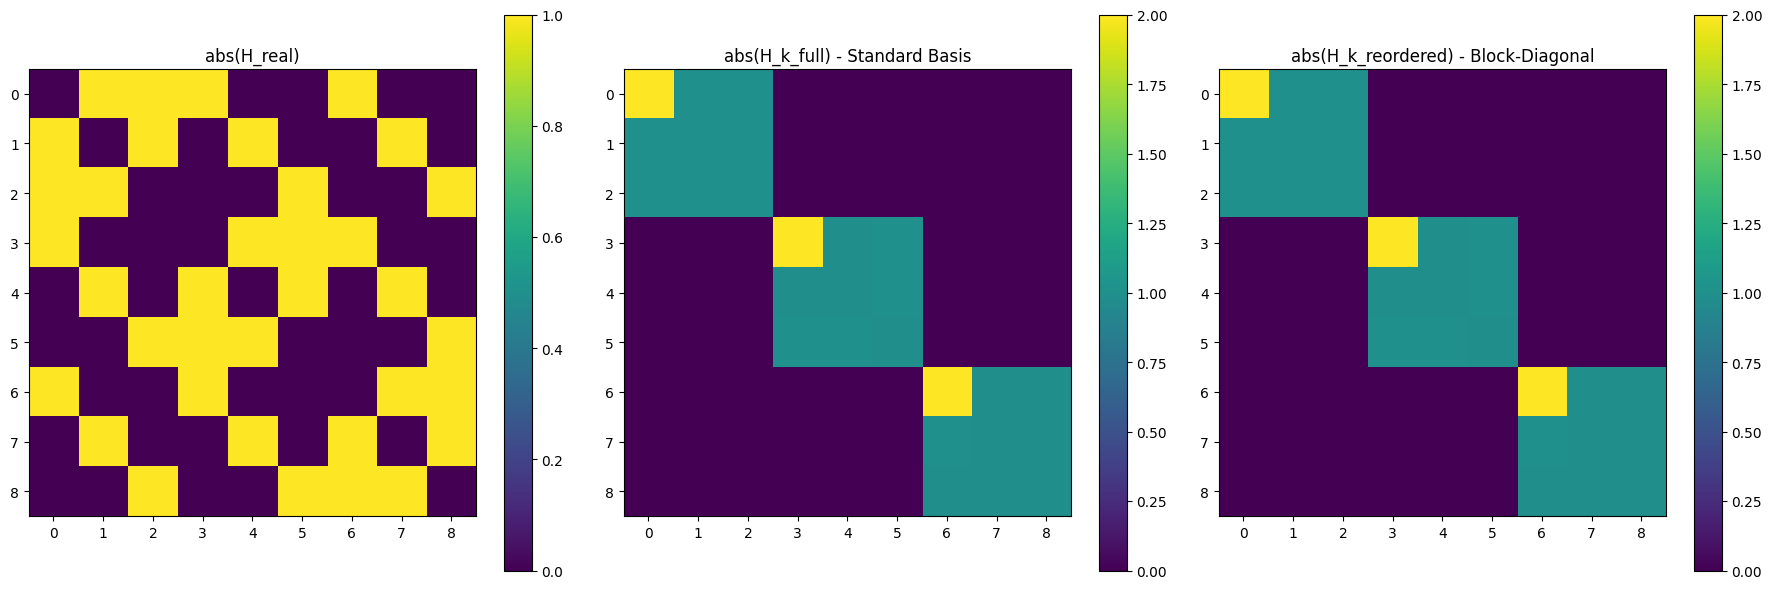

In [10]:
visualize_matrices(N=N, L_x=L_x, L_y=L_y, PBC_x=PBC_x, PBC_y=PBC_y, T_x=T_x, T_y=T_y, p=p, q=q)


In [11]:
def get_bands_in_MBZ(N, L_x, L_y, PBC_x, PBC_y, T_x, T_y, p, q):
    L_x_q = L_x // q  # Reduced size for the block structure
    bands_per_k=np.zeros((L_x_q, L_y, q), dtype=float) #this is the list of bands per k
    state_list=get_state_list(N=N, L_x=L_x, L_y=L_y)
    H_real = get_hamiltonian_for_fixed_number_of_electrons(N=N, state_list=state_list,L_x=L_x, L_y=L_y, PBC_x=PBC_x, PBC_y=PBC_y, T_x=T_x, T_y=T_y, p=p, q=q , progress_bar=True)
    U = get_fourier_transform_matrix(L_x, L_y)
    H_k_full = U @ H_real @ U.conj().T
    H_k_reordered = reorder_k_basis(H_k_full, L_x, L_y, q)
    for l in range(L_y):  # ky index
        for j_reduced in range(L_x_q):  # reduced kx index
            # Calculate the position of the (j_reduced, l) block on the diagonal
            block_index = l * L_x_q + j_reduced
            start_idx = block_index * q
            end_idx = start_idx + q

            # Extract the q x q block
            small_block = H_k_reordered[start_idx:end_idx, start_idx:end_idx]

            # Diagonalize the block to get the energy bands at this k-point
            eigenvalues = np.linalg.eigvalsh(small_block)
            bands_per_k[j_reduced, l, :] = eigenvalues
            
    print("\nCalculation complete. Bands are stored.")
    return bands_per_k


def get_kx_ky_energies(bands, m, n, q, L_x, L_y):
    k_x=m*2*np.pi*q/L_x
    k_y=n*2*np.pi/L_y
    energies=bands[m,n,:]
    return k_x, k_y, energies
    



Generating plot of Energy vs. k_y...

Calculation complete. Bands are stored.


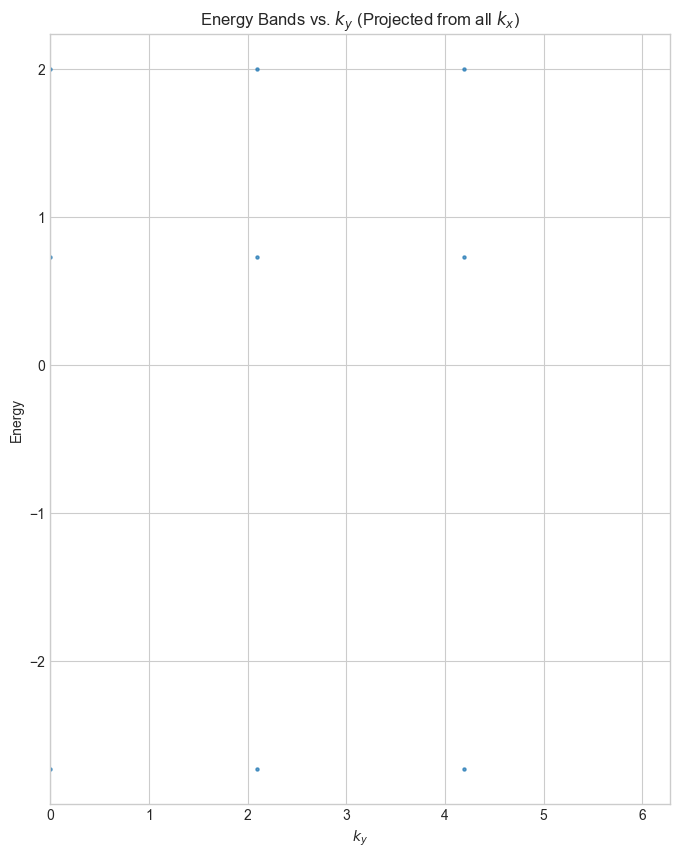

In [12]:
print("Generating plot of Energy vs. k_y...")
bands_per_k = get_bands_in_MBZ(N=N, L_x=L_x, L_y=L_y, PBC_x=PBC_x, PBC_y=PBC_y, T_x=T_x, T_y=T_y, p=p, q=q)
Lx_q, L_y_from_data, q = bands_per_k.shape
if L_y_from_data != L_y:
    raise ValueError("L_y parameter does not match data shape.")

# Create the k_y momentum values for the x-axis
ky_vals = np.linspace(0, 2 * np.pi, L_y, endpoint=False)

# Prepare data for plotting
plot_energies = []
plot_ky = []

# For each k_y, collect all energies from all k_x values
for l in range(L_y):
    # Get all energies for this k_y (shape is (Lx_q, q))
    energies_at_ky = bands_per_k[:, l, :].flatten()
    
    # Append data for scatter plot
    plot_energies.extend(energies_at_ky)
    plot_ky.extend([ky_vals[l]] * len(energies_at_ky))

# Create the plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(plot_ky, plot_energies, s=5, alpha=0.7)

ax.set_title(f'Energy Bands vs. $k_y$ (Projected from all $k_x$)')
ax.set_xlabel('$k_y$')
ax.set_ylabel('Energy')
ax.set_xlim(0, 2 * np.pi)
plt.show()

In [13]:
get_bands_in_MBZ(N=N, L_x=L_x, L_y=L_y, PBC_x=PBC_x, PBC_y=PBC_y, T_x=T_x, T_y=T_y, p=p, q=q)


Calculation complete. Bands are stored.


array([[[-2.732,  0.732,  2.   ],
        [-2.732,  0.732,  2.   ],
        [-2.732,  0.732,  2.   ]]])

In [14]:
a=np.zeros((2,2),dtype=int)
a[1,1]=1
print(a)

[[0 0]
 [0 1]]


### Directly in k-space for 1 particle

#### Fourier transform only on k_y

In [15]:

def build_harper_hamiltonian(k_y, L_x, T_x, T_y,  p,q, PBC_x):
    if L_x % q != 0:
        raise ValueError("L_x must be divisible by q")
    """
    
    The Hamiltonian is given by:
    H = sum_x [-t(c_x+1^dag c_x + H.c.) + V_x c_x^dag c_x]
    where V_x = 2 * cos(2*pi*alpha*x + ky)

    """
    # Initialize an Nx x Nx zero matrix. The matrix is real, so we use float.
    H = np.zeros((L_x, L_x), dtype=float)

    # --- Vectorized approach to build the matrix ---

    # 1. Create the diagonal (on-site potential) elements
    # The potential V_x depends on the site index x.
    site_indices = np.arange(L_x)
    diagonal_values = -2 * T_y * np.cos(2 * np.pi * p * site_indices / q + k_y)
    
    # Use np.diag to place these values on the main diagonal of H
    np.fill_diagonal(H, diagonal_values)

    # 2. Create the off-diagonal (hopping) elements
    # These represent hopping to the nearest neighbor with amplitude -t.
    off_diagonal_values = -T_x * np.ones(L_x - 1)
    
    # Use np.diag with k=1 for the upper off-diagonal and k=-1 for the lower
    H += np.diag(off_diagonal_values, k=1)
    H += np.diag(off_diagonal_values, k=-1)

    # 3. Apply Periodic Boundary Conditions (PBC)
    # This connects the last site (Nx-1) back to the first site (0).
    # This corresponds to the corner elements of the matrix.
    if PBC_x:
        H[0, L_x - 1] = -T_x
        H[L_x - 1, 0] = -T_x

    return H

In [16]:
def plot_energy_bands_for_ky(L_x, L_y, T_x, T_y, p, q, PBC_x):
    # Generate k_y values from 0 to 2*pi
    k_y_values = np.linspace(0, 2 * np.pi, L_y)
    energy_bands = []
    ipr_values = []
    # Compute the eigenvalues for each k_y
    for k_y in k_y_values:
        H = build_harper_hamiltonian(k_y, L_x, T_x, T_y, p, q, PBC_x)
        eigenvalues, eigenvectors = np.linalg.eigh(H)  # Compute eigenvalues
        energy_bands.append(eigenvalues)

        ipr_values_per_ky = []
        for i in range(len(eigenvalues)):
            ipr = calculate_IPR(eigenvectors[:, i])
            ipr_values_per_ky.append(ipr)
            
        ipr_values.append(ipr_values_per_ky)

    # Convert energy bands and ipr_values to numpy arrays for easier manipulation
    energy_bands = np.array(energy_bands)
    ipr_values = np.array(ipr_values)

    # Normalize IPR values for color mapping
    norm = Normalize(vmin=np.min(ipr_values), vmax=np.max(ipr_values))
    colormap = cm.get_cmap('cool')  # You can choose any colormap

    # Plot the energy bands
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('black')  # Set figure background to black beacuse its cool
    ax.set_facecolor('black')
    
    for i in range(L_x):
        for j in range(L_y - 1):  # Plot segment by segment to assign colors dynamically
            color = colormap(norm(ipr_values[j, i]))
            plt.plot(k_y_values[j:j+2], energy_bands[j:j+2, i], color=color)  # [j:j+2] is to plot each segment


    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array(ipr_values.flatten())  # Associate the mappable with the data
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Ipr', fontsize=14, color='white')  # Set label color to white
    cbar.ax.tick_params(labelsize=12, colors='white')  # Set tick color to white

    # add a colorbar on the side for logaithmic scale
    # sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    # sm.set_array(ipr_values.flatten())
    # log_vmin = np.log10(np.min(ipr_values) + 1e-9)
    # log_vmax = np.log10(np.max(ipr_values))
    # ticks_to_show = np.logspace(log_vmin, log_vmax, 5) #choose number of vlaues to show in colorbar
    # cbar = plt.colorbar(sm, ax=ax, ticks=ticks_to_show)
    # cbar.ax.set_yticklabels([f'{t:.2f}' for t in ticks_to_show])
    # cbar.set_label('IPR (Log Scale)', rotation=270, labelpad=20)
    # cbar.ax.tick_params(labelsize=12)

    ax.set_xlabel(r'$k_y$', fontsize=14, color='white')  # Set label color to white
    ax.set_ylabel('Energy', fontsize=14, color='white')  # Set label color to white
    ax.set_title('Energy Bands vs $k_y$', fontsize=16, color='white')  # Set title color to white
    ax.tick_params(colors='white')  # Set tick color to white
    ax.grid(color='gray', linestyle='--', linewidth=0.5)  # Set grid color to gray

    # Set x-ticks to 0, pi, and 2*pi with LaTeX formatting
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=12, color='white')

    plt.xlabel(r'$k_y$', fontsize=14)
    plt.ylabel('Energy', fontsize=14)
    plt.title('Energy Bands vs $k_y$', fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_20595/2004847686.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('cool')  # You can choose any colormap


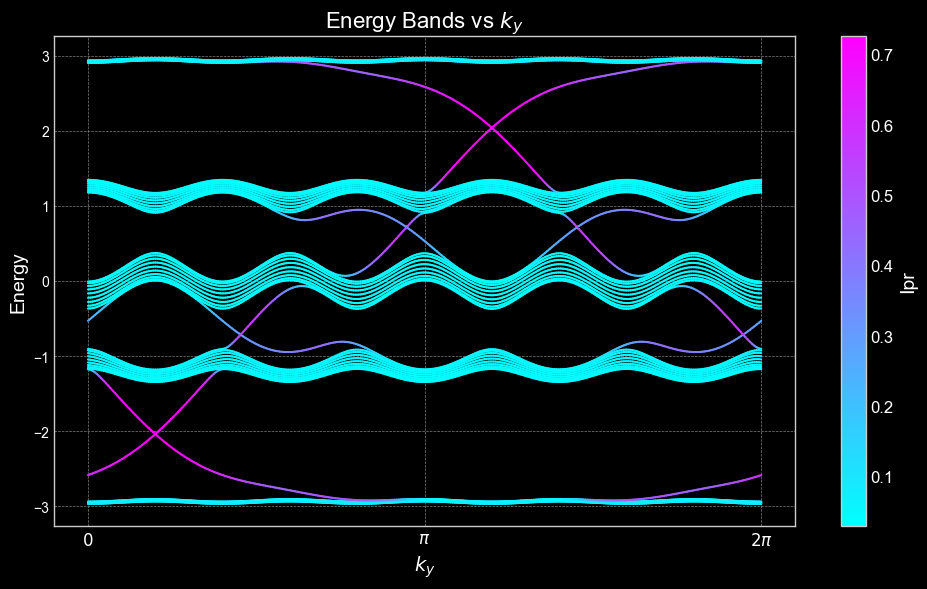

In [17]:


L_x = 50  # Number of sites in x-direction
L_y = 300  # Number of sites in y-direction (not used here)
T_x = 1.0  # Hopping amplitude
T_y = 1.0  # Potential modulation amplitude
p = 1      # Numerator of magnetic flux per plaquette
q = 5      # Denominator of magnetic flux per plaquette
PBC_x = False  # Periodic boundary conditions
PBC_y = True  # Periodic boundary conditions in y-direction (not used here)

plot_energy_bands_for_ky(L_x, L_y, T_x, T_y, p, q, PBC_x)

#### Fourier on k_x and k_y

In [32]:
def build_kspace_hamiltonian(k_x, k_y, L_x, L_y, T_x, T_y, p, q , PBC_x, PBC_y):

    if PBC_x == False or PBC_y == False:
        raise ValueError("This function is designed for periodic boundary conditions  only.")
    if L_x % q != 0:
        raise ValueError("L_x must be divisible by q for the Harper model.")
    """
    Builds the matrix for a 1D chain with complex hopping and a cosine potential.

    
    k_x and k_y are defined in THE MBZ, so 0<k_x<2pi/q and 0<k_y<2pi. !!!!!!!!!!!!!
    
    The Hamiltonian for a given (kx, ky) is:
    H(kx, ky) = sum_j [ -Tx * (e^(-i*2*pi*kx) c_j+1^dag c_j + H.c.) + V_j c_j^dag c_j ]
    where V_j = 2 * Ty * cos(2*pi*alpha*j + ky)


    """
    H = np.zeros((q, q), dtype=complex)
    site_indices = np.arange(q)
    # --- Vectorized approach to build the matrix ---

    # 1. Create the diagonal (on-site potential) elements
    diagonal_values = -2 * T_y * np.cos(2 * np.pi * p / q * site_indices + k_y)
    np.fill_diagonal(H, diagonal_values)

    # 2. Create the off-diagonal (hopping) elements
    upper_off_diag_val = -T_x * np.exp(-1j * 2 * np.pi * k_x)
    lower_off_diag_val = -T_x * np.exp(1j * 2 * np.pi * k_x)

    # Fill the upper and lower off-diagonals
    H += np.diag(upper_off_diag_val * np.ones(q - 1, dtype=complex), k=1)
    H += np.diag(lower_off_diag_val * np.ones(q - 1, dtype=complex), k=-1)

    # 3. Apply Periodic Boundary Conditions (PBC)
    
    H[0, q - 1] = upper_off_diag_val
    H[q - 1, 0] = lower_off_diag_val

    return H

def calculate_chern_number(eigenvectors, L_x, L_y, band_index):
    '''
        eigenvectors must be a four dim array wih values [k_y, k_x, band index, components of eigenvector in q basis]
    '''
    total_berry_flux = 0.0
    for j in range(L_x//q):
        for i in range(L_y):
            # Get the four eigenvectors for the plaquette corners
            uk = eigenvectors[i, j, band_index]
            uk_dy = eigenvectors[(i + 1) % (L_y), j, band_index] # Neighbor in +kx
            uk_dx = eigenvectors[i, (j + 1) % (L_x//q), band_index] # Neighbor in +ky
            uk_dx_dy = eigenvectors[(i + 1) % L_y, (j + 1) % (L_x//q), band_index]

            # Compute Link Variables (inner products)
            # The order is important for the final product
            link_0_dx = np.vdot(uk, uk_dx)
            link_dx_dxdy = np.vdot(uk_dx, uk_dx_dy)
            link_dxdy_dy = np.vdot(uk_dx_dy, uk_dy)
            link_dy_0 = np.vdot(uk_dy, uk)

            # Calculate Plaquette Flux (argument of the product of links)
            plaquette_flux = np.angle(link_0_dx * link_dx_dxdy * link_dxdy_dy * link_dy_0)
            total_berry_flux += plaquette_flux

    #Sum and Normalize
    chern_number = total_berry_flux / (2 * np.pi)
    
    return chern_number


In [27]:
def plot_energy_bands_per_ky_kx(L_x, L_y, T_x, T_y, p, q , PBC_x, PBC_y):
    k_y_values = np.linspace(0, 2 * np.pi, L_y, endpoint=False)  # k_y values from 0 to 2*pi
    energy_bands = []
    k_x_values = np.linspace(0, 2 * np.pi / q, L_x // q, endpoint=False)  # k_x values from 0 to 2*pi/q


    energies = np.zeros((L_y, L_x//q, q))
    eigenvectors = np.zeros(( L_y, L_x//q, q, q), dtype=complex)


    # 2. Calculate eigenvalues for each point on the (kx, ky) grid
    for i, k_x in enumerate(k_x_values):
        for j, k_y in enumerate(k_y_values):
            H = build_kspace_hamiltonian(k_x=k_x, k_y=k_y, L_x=L_x, L_y=L_y, T_x=T_x, T_y=T_y, p=p, q=q, PBC_x=PBC_x, PBC_y=PBC_y)
            # Store the sorted eigenvalues
            eigvals, eigvecs= np.linalg.eigh(H) #prima indicie di rigaporcaputtana
            energies[j, i, :] = eigvals # Store the eigenvalues for this (kx, ky) point
            for band_index in range(q):
                # Store the eigenvector corresponding to the band_index
                # Note: eigvecs[:, band_index] gives the eigenvector for the band_index at (kx, ky)
                eigenvectors[j, i, band_index, :] = eigvecs[:, band_index] #meeded to calulate chern number

 
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    
    Kx, Ky = np.meshgrid(k_x_values, k_y_values)
    for band_index in range(q):
        ax.plot_surface(Kx, Ky, energies[:, :, band_index], cmap='viridis', edgecolor='none', alpha=0.8)


    ax.set_xticks([0, np.pi/q, 2 * np.pi/q])
    ax.set_xticklabels([r'$0$', r'$\pi/q$', r'$2\pi/q$'], fontsize=12, color='black')
    ax.set_yticks([0, np.pi, 2 * np.pi])
    ax.set_yticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=12, color='black')

    ax.set_xlabel('$k_x$', fontsize=14)
    ax.set_ylabel('$k_y$', fontsize=14)
    ax.set_zlabel('Energy', fontsize=14)
    ax.set_title(f'3D Energy Bands for $\\alpha = {p/q}$', fontsize=16)
    
    # Improve viewing angle
    ax.view_init(elev=20, azim=-65)
    
    plt.tight_layout()
    plt.show()
    

/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_20595/1325891413.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


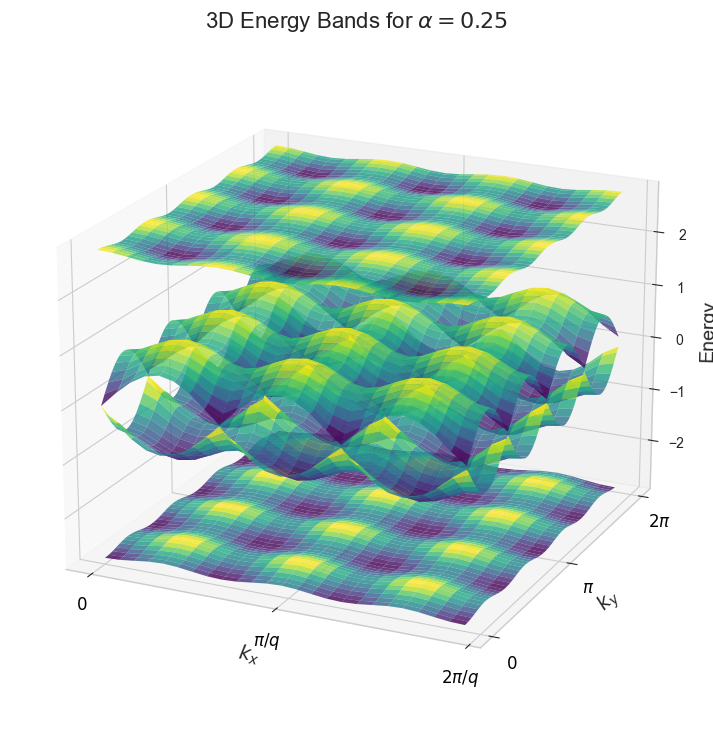

In [28]:
L_x = 100  # Number of sites in x-direction
L_y = 100  # Number of sites in y-direction
T_x = 1.0  # Hopping amplitude
T_y = 1.0  # Potential modulation amplitude
p = 1      # Numerator of magnetic flux per plaquette
q = 4      # Denominator of magnetic flux per plaquette
PBC_x = True  # Periodic boundary conditions in x-direction
PBC_y = True  # Periodic boundary conditions in y-direction
plot_energy_bands_per_ky_kx( L_x=L_x, L_y=L_y, T_x=T_x, T_y=T_y, p=p, q=q, PBC_x=PBC_x, PBC_y=PBC_y)

In [43]:
def plot_energy_bands_per_kx(L_x, L_y, T_x, T_y, p, q, PBC_x, PBC_y):
    k_y_values = np.linspace(0, 2 * np.pi, L_y, endpoint=False)  # k_y values from 0 to 2*pi
    k_x_values = np.linspace(0, 2 * np.pi / q, L_x // q, endpoint=False)  # k_x values from 0 to 2*pi/q
    energies = np.zeros((L_y, L_x//q, q))
    eigenvectors = np.zeros((L_y, L_x//q, q, q), dtype=complex)

    # Calculate eigenvalues for each point on the (kx, ky) grid
    for i, k_x in enumerate(k_x_values):
        for j, k_y in enumerate(k_y_values):
            H = build_kspace_hamiltonian(k_x=k_x, k_y=k_y, L_x=L_x, L_y=L_y, T_x=T_x, T_y=T_y, p=p, q=q, PBC_x=PBC_x, PBC_y=PBC_y)
            eigvals, eigvecs = np.linalg.eigh(H)
            energies[j, i, :] = eigvals
            for band_index in range(q):
                eigenvectors[j, i, band_index, :] = eigvecs[:, band_index]

    chern_numbers = [calculate_chern_number(eigenvectors, L_x, L_y, band_index) for band_index in range(q)]
    norm = Normalize(vmin=min(chern_numbers), vmax=max(chern_numbers))
    colormap = cm.get_cmap('rainbow')

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('black')  # Set figure background to black
    ax.set_facecolor('black')  # Set axes background to black

    for band_index in range(q):
        chern_number = chern_numbers[band_index]
        print(f'Band {band_index}, Chern Number: {chern_number}')
        color = colormap(norm(chern_number))
        for i, k_y in enumerate(k_y_values):
            ax.plot(k_x_values, energies[i, :, band_index], color=color)

    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array(chern_numbers)
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Chern Number', fontsize=14, color='white')
    cbar.ax.tick_params(labelsize=12, colors='white')

    ax.set_xticks([0, np.pi/q, 2 * np.pi/q])
    ax.set_xticklabels([r'$0$', r'$\pi/q$', r'$2\pi/q$'], fontsize=12, color='white')
    ax.set_xlabel(r'$k_x$', fontsize=14, color='white')
    ax.set_ylabel('Energy', fontsize=14, color='white')
    ax.set_title(f'Energy Bands vs $k_x$ for $\\alpha = {p/q}$', fontsize=16, color='white')
    ax.tick_params(colors='white')
    ax.grid(color='gray', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.show()




def plot_energy_bands_per_ky(L_x, L_y, T_x, T_y, p, q, PBC_x, PBC_y):
    k_y_values = np.linspace(0, 2 * np.pi, L_y, endpoint=False)  # k_y values from 0 to 2*pi
    k_x_values = np.linspace(0, 2 * np.pi / q, L_x // q, endpoint=False)  # k_x values from 0 to 2*pi/q
    energies = np.zeros((L_y, L_x//q, q))
    eigenvectors = np.zeros((L_y, L_x//q, q, q), dtype=complex)

    for i, k_x in enumerate(k_x_values):
        for j, k_y in enumerate(k_y_values):
            H = build_kspace_hamiltonian(k_x=k_x, k_y=k_y, L_x=L_x, L_y=L_y, T_x=T_x, T_y=T_y, p=p, q=q, PBC_x=PBC_x, PBC_y=PBC_y)
            eigvals, eigvecs = np.linalg.eigh(H)
            energies[j, i, :] = eigvals
            for band_index in range(q):
                eigenvectors[j, i, band_index, :] = eigvecs[:, band_index]

    chern_numbers = [calculate_chern_number(eigenvectors, L_x, L_y, band_index) for band_index in range(q)]
    norm = Normalize(vmin=min(chern_numbers), vmax=max(chern_numbers))
    colormap = cm.get_cmap('rainbow')

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('black')  # Set figure background to black
    ax.set_facecolor('black')  # Set axes background to black

    for band_index in range(q):
        chern_number = chern_numbers[band_index]
        print(f'Band {band_index}, Chern Number: {chern_number}, rounded: {round(chern_number)}')
        color = colormap(norm(chern_number))
        for i, k_x in enumerate(k_x_values):
            ax.plot(k_y_values, energies[:, i, band_index], color=color)

    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array(chern_numbers)
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Chern Number', fontsize=14, color='white')
    cbar.ax.tick_params(labelsize=12, colors='white')

    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'], fontsize=12, color='white')
    ax.set_xlabel(r'$k_y$', fontsize=14, color='white')
    ax.set_ylabel('Energy', fontsize=14, color='white')
    ax.set_title(f'Energy Bands vs $k_y$ for $\\alpha = {p}/{q}$', fontsize=16, color='white')
    ax.tick_params(colors='white')
    ax.grid(color='gray', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.show()


Band 0, Chern Number: 4.9999999999999964, rounded: 5
Band 1, Chern Number: 2.0, rounded: 2
Band 2, Chern Number: -2.999999999999996, rounded: -3
Band 3, Chern Number: -8.000000000000005, rounded: -8
Band 4, Chern Number: -3.0000000000000013, rounded: -3
Band 5, Chern Number: 2.0000000000000004, rounded: 2
Band 6, Chern Number: 5.000000000000001, rounded: 5


/var/folders/z4/q3_z78fj4gldz7hpcmkdj1y00000gn/T/ipykernel_20595/4118750146.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('rainbow')


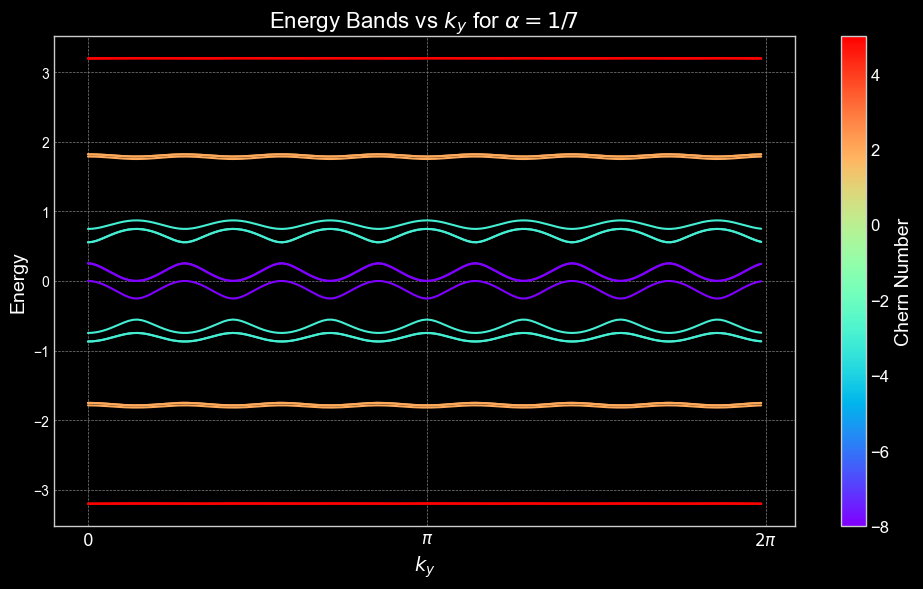

In [44]:


# Example usage
L_x = 21  # Number of sites in x-direction
L_y = 150  # Number of sites in y-direction
T_x = 1.0  # Hopping amplitude
T_y = 1.0  # Potential modulation amplitude
p = 1      # Numerator of magnetic flux per plaquette
q = 7      # Denominator of magnetic flux per plaquette
PBC_x = True  # Periodic boundary conditions in x-direction
PBC_y = True  # Periodic boundary conditions in y-direction

plot_energy_bands_per_ky(L_x, L_y, T_x, T_y, p, q, PBC_x, PBC_y)